# SKAB Valve 1 (Experiment 0) - Univariate vs Multivariate Anomaly Detection

*Note on Baseline Selection:* According to the SKAB authors' own examples, the baseline should be established using the first 400 normal observations of the sequence itself, rather than `anomaly-free.csv`, because of varying operational states.

In [34]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from scipy.spatial.distance import mahalanobis
from scipy.stats import f, chi2
from sklearn.metrics import f1_score, precision_score, recall_score, confusion_matrix

# Define features
features = ['Accelerometer1RMS', 'Accelerometer2RMS', 'Current',
            'Pressure', 'Temperature', 'Thermocouple', 'Voltage', 'Volume Flow RateRMS']

# Load test data (valve1/0.csv)
test = pd.read_csv('../data/SKAB/valve1/0.csv', sep=';', index_col='datetime', parse_dates=True)

# Establish baseline from the first 400 rows of the test sequence (normal operation)
train = test.iloc[:400]

def print_metrics(y_true, y_pred, label):
    cm = confusion_matrix(y_true, y_pred)
    tn, fp, fn, tp = cm.ravel()
    precision = precision_score(y_true, y_pred)
    recall = recall_score(y_true, y_pred)
    f1 = f1_score(y_true, y_pred)
    
    print(f"--- {label} ---")
    print(f"Confusion Matrix: [TN: {tn}, FP: {fp} / FN: {fn}, TP: {tp}]")
    print(f"Precision: {precision:.4f}")
    print(f"Recall:    {recall:.4f}")
    print(f"F1 Score:  {f1:.4f}")
    print("-" * (len(label) + 8))
    return f1


## 2. Univariate Z-Score Baseline

In [35]:
# Compute univariate statistics from training data
mu_univ = train[features].mean()
std_univ = train[features].std()

# Compute Z-scores for test data
z_scores = (test[features] - mu_univ) / std_univ

# Threshold for Z-score (e.g., 3 sigma)
threshold_z = 3.0

# Identify anomalies for each sensor independently
for col in features:
    test[f'anomaly_z_{col}'] = (np.abs(z_scores[col]) > threshold_z).astype(int)

# Combined univariate anomaly (if ANY sensor triggers)
test['anomaly_z_combined'] = test[[f'anomaly_z_{col}' for col in features]].max(axis=1)

f1_univ = print_metrics(test['anomaly'], test['anomaly_z_combined'], "Univariate Z-Score (Combined)")


--- Univariate Z-Score (Combined) ---
Confusion Matrix: [TN: 573, FP: 173 / FN: 57, TP: 344]
Precision: 0.6654
Recall:    0.8579
F1 Score:  0.7495
-------------------------------------


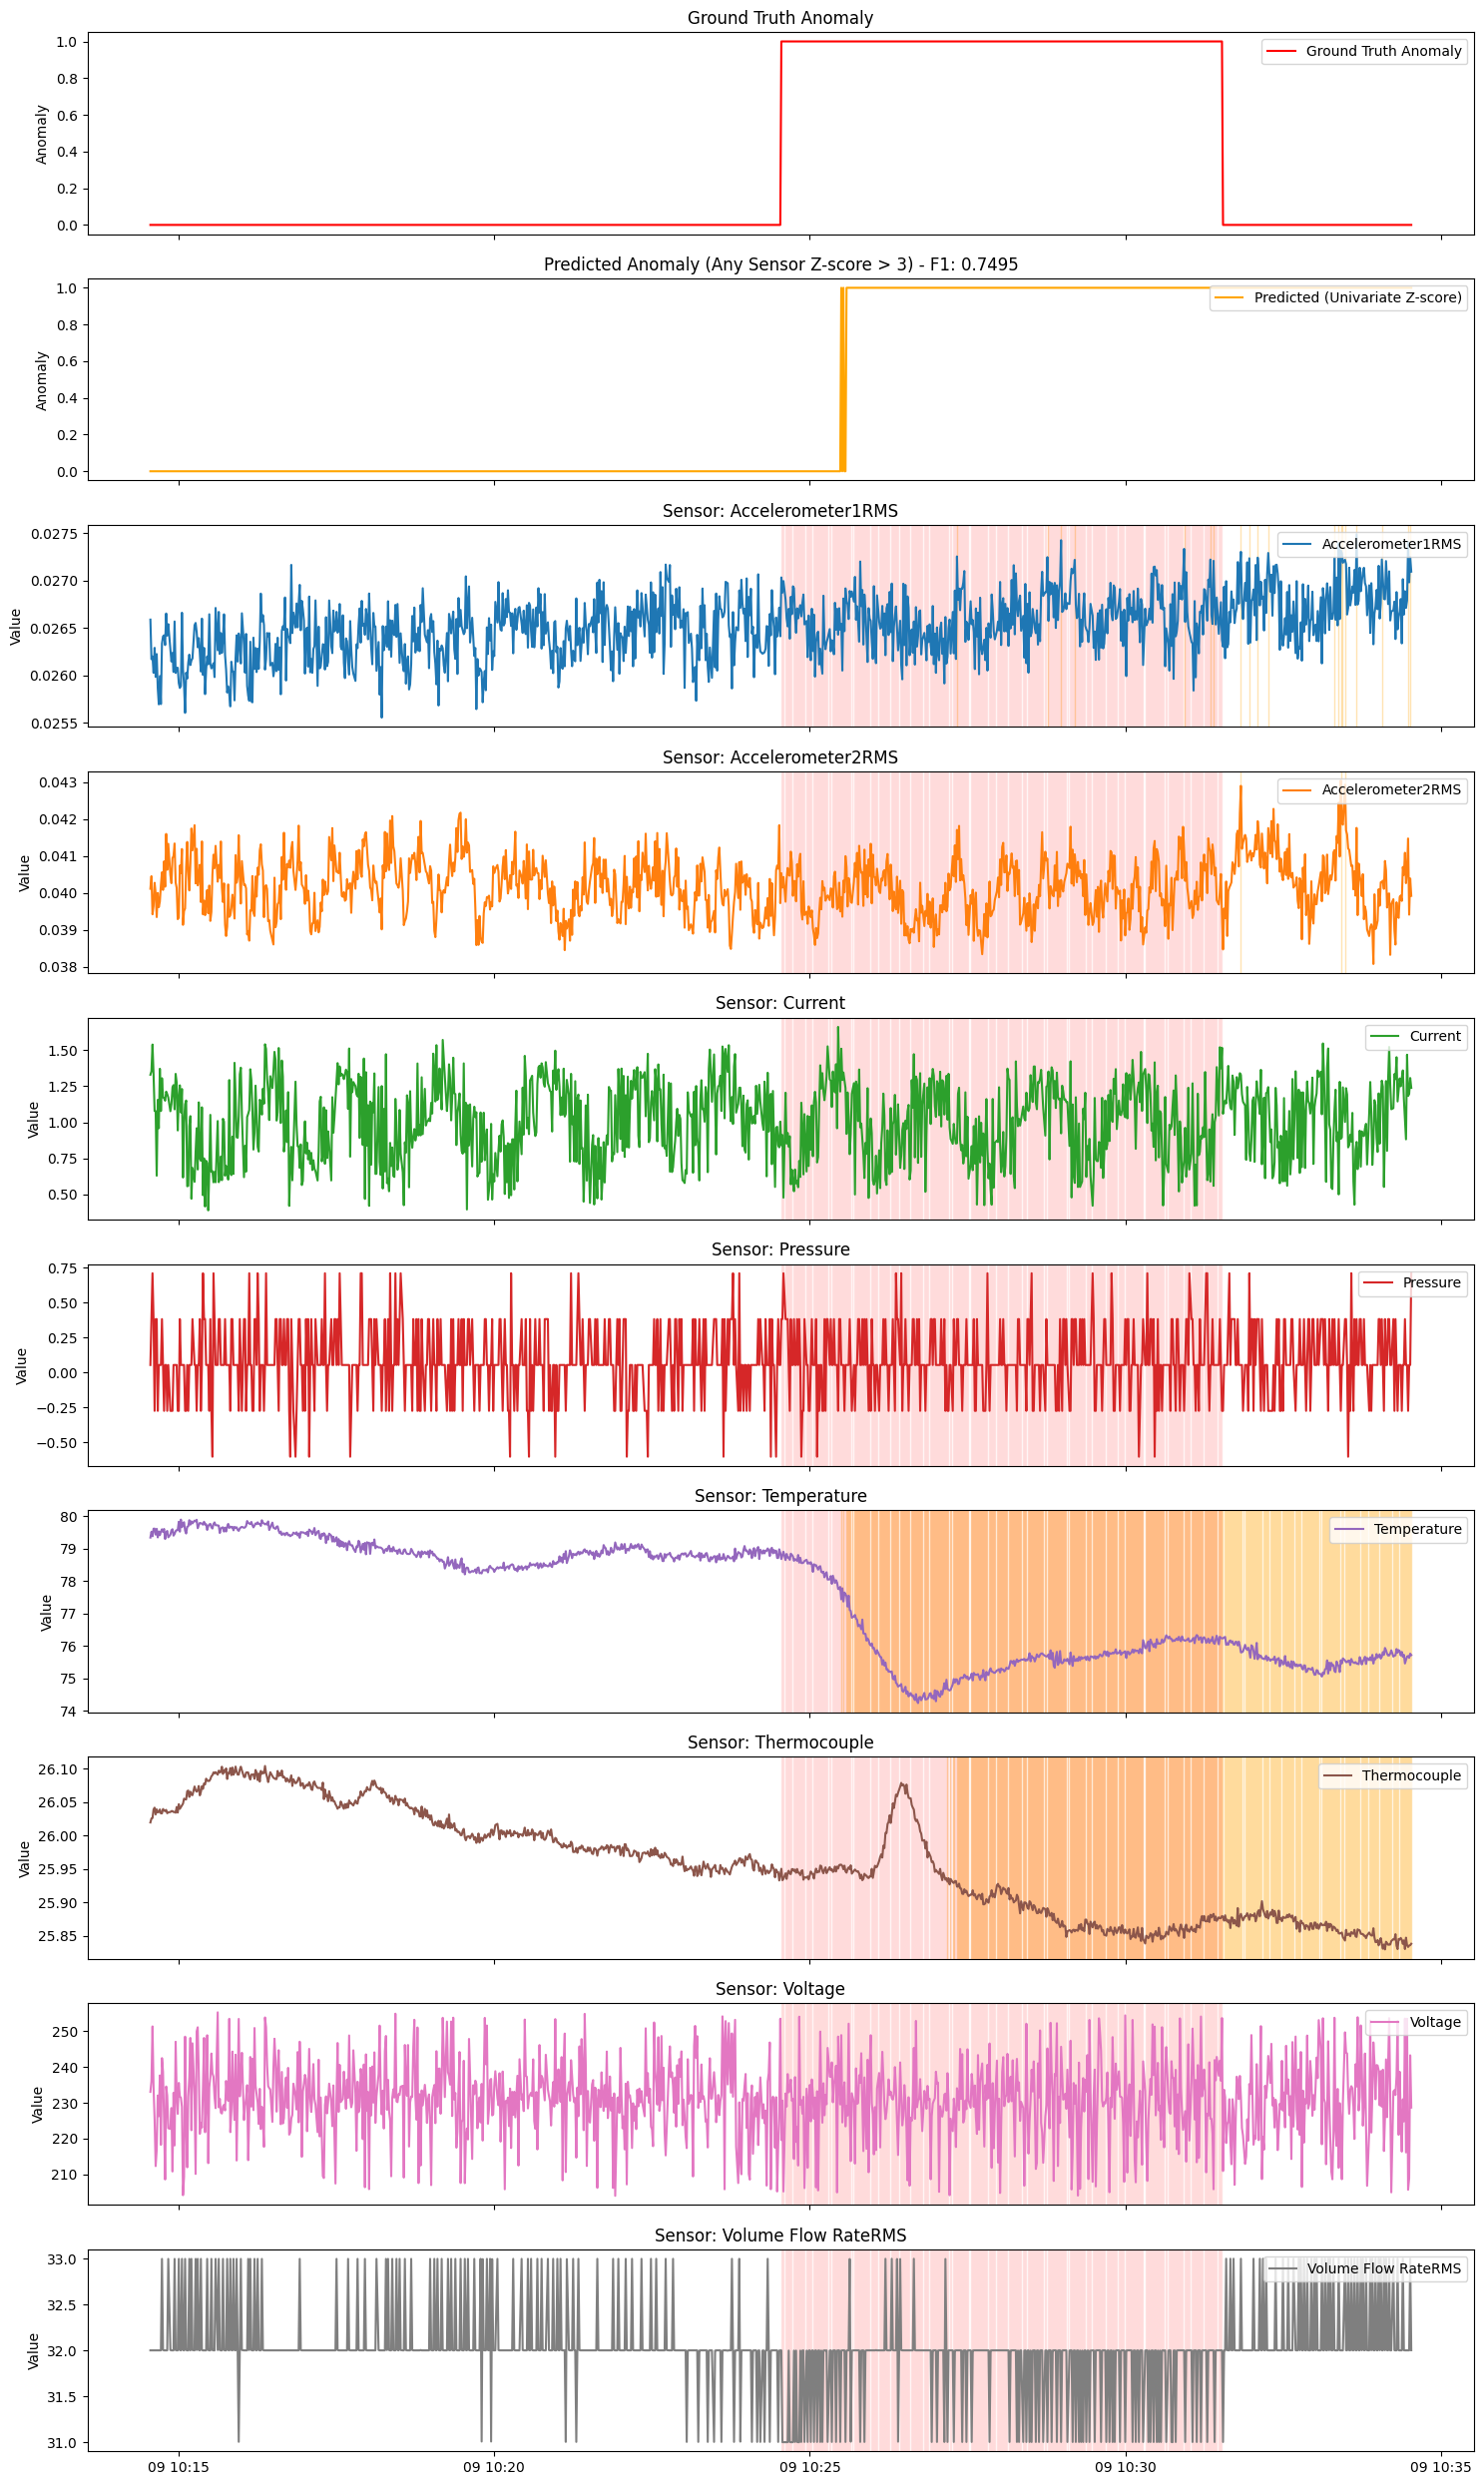

In [36]:
# Plot Univariate Z-Score Predictions
fig, axes = plt.subplots(nrows=len(features) + 2, ncols=1, figsize=(15, 25), sharex=True)

axes[0].plot(test.index, test['anomaly'], color='red', label='Ground Truth Anomaly')
axes[0].set_title('Ground Truth Anomaly')
axes[0].set_ylabel('Anomaly')
axes[0].legend(loc='upper right')

axes[1].plot(test.index, test['anomaly_z_combined'], color='orange', label='Predicted (Univariate Z-score)')
axes[1].set_title(f'Predicted Anomaly (Any Sensor Z-score > 3) - F1: {f1_univ:.4f}')
axes[1].set_ylabel('Anomaly')
axes[1].legend(loc='upper right')

for i, col in enumerate(features):
    ax = axes[i + 2]
    ax.plot(test.index, test[col], color=f'C{i}', label=col)
    
    anomalies = test[test[f'anomaly_z_{col}'] == 1].index
    for anomaly_time in anomalies:
        ax.axvspan(anomaly_time, anomaly_time, color='orange', alpha=0.3)
        
    gt_anomalies = test[test['anomaly'] == 1].index
    for gt_time in gt_anomalies:
        ax.axvspan(gt_time, gt_time, color='red', alpha=0.1)
        
    ax.set_title(f'Sensor: {col}')
    ax.set_ylabel('Value')
    ax.legend(loc='upper right')

plt.tight_layout()
plt.show()


## 3. Multivariate Mahalanobis Distance with Contribution Analysis\n\nTo find out which sensor contributed the most to the anomaly, we decompose the squared Mahalanobis distance into components for each feature. The squared distance $D^2 = (x - \mu)^T \Sigma^{-1} (x - \mu)$ can be decomposed into a sum of contributions $C_i = (x_i - \mu_i) \cdot (\Sigma^{-1}(x - \mu))_i$.

In [37]:
# Compute multivariate statistics from training data
mu_multiv = train[features].mean().values
cov_multiv = train[features].cov().values
cov_inv = np.linalg.pinv(cov_multiv)

# Compute diff matrix
diff = test[features].values - mu_multiv

# Compute contributions C_i
# (diff @ cov_inv) computes the right term of the dot product for all rows simultaneously
contributions = diff * (diff @ cov_inv)

# The sum of contributions across features for a row equals its squared Mahalanobis distance
test['t2_score'] = contributions.sum(axis=1)

# Find the sensors with the top 2 absolute contributions for each timestamp
top2_contrib_indices = np.argsort(np.abs(contributions), axis=1)[:, -2:]
test['mahal_top1_contributor'] = [features[idx[1]] for idx in top2_contrib_indices]
test['mahal_top2_contributor'] = [features[idx[0]] for idx in top2_contrib_indices]

# Threshold based on Chi-Squared distribution with p degrees of freedom (alpha=0.001)
p = len(features)
threshold_999 = chi2.ppf(0.999, df=p)

print(f"Chi-Squared Threshold (99.9%): {threshold_999:.4f}")

# Identify anomalies using Mahalanobis distance squared
test['anomaly_mahal'] = (test['t2_score'] > threshold_999).astype(int)

f1_mahal = print_metrics(test['anomaly'], test['anomaly_mahal'], "Multivariate Mahalanobis (Chi2 Threshold)")


Chi-Squared Threshold (99.9%): 26.1245
--- Multivariate Mahalanobis (Chi2 Threshold) ---
Confusion Matrix: [TN: 555, FP: 191 / FN: 47, TP: 354]
Precision: 0.6495
Recall:    0.8828
F1 Score:  0.7484
-------------------------------------------------


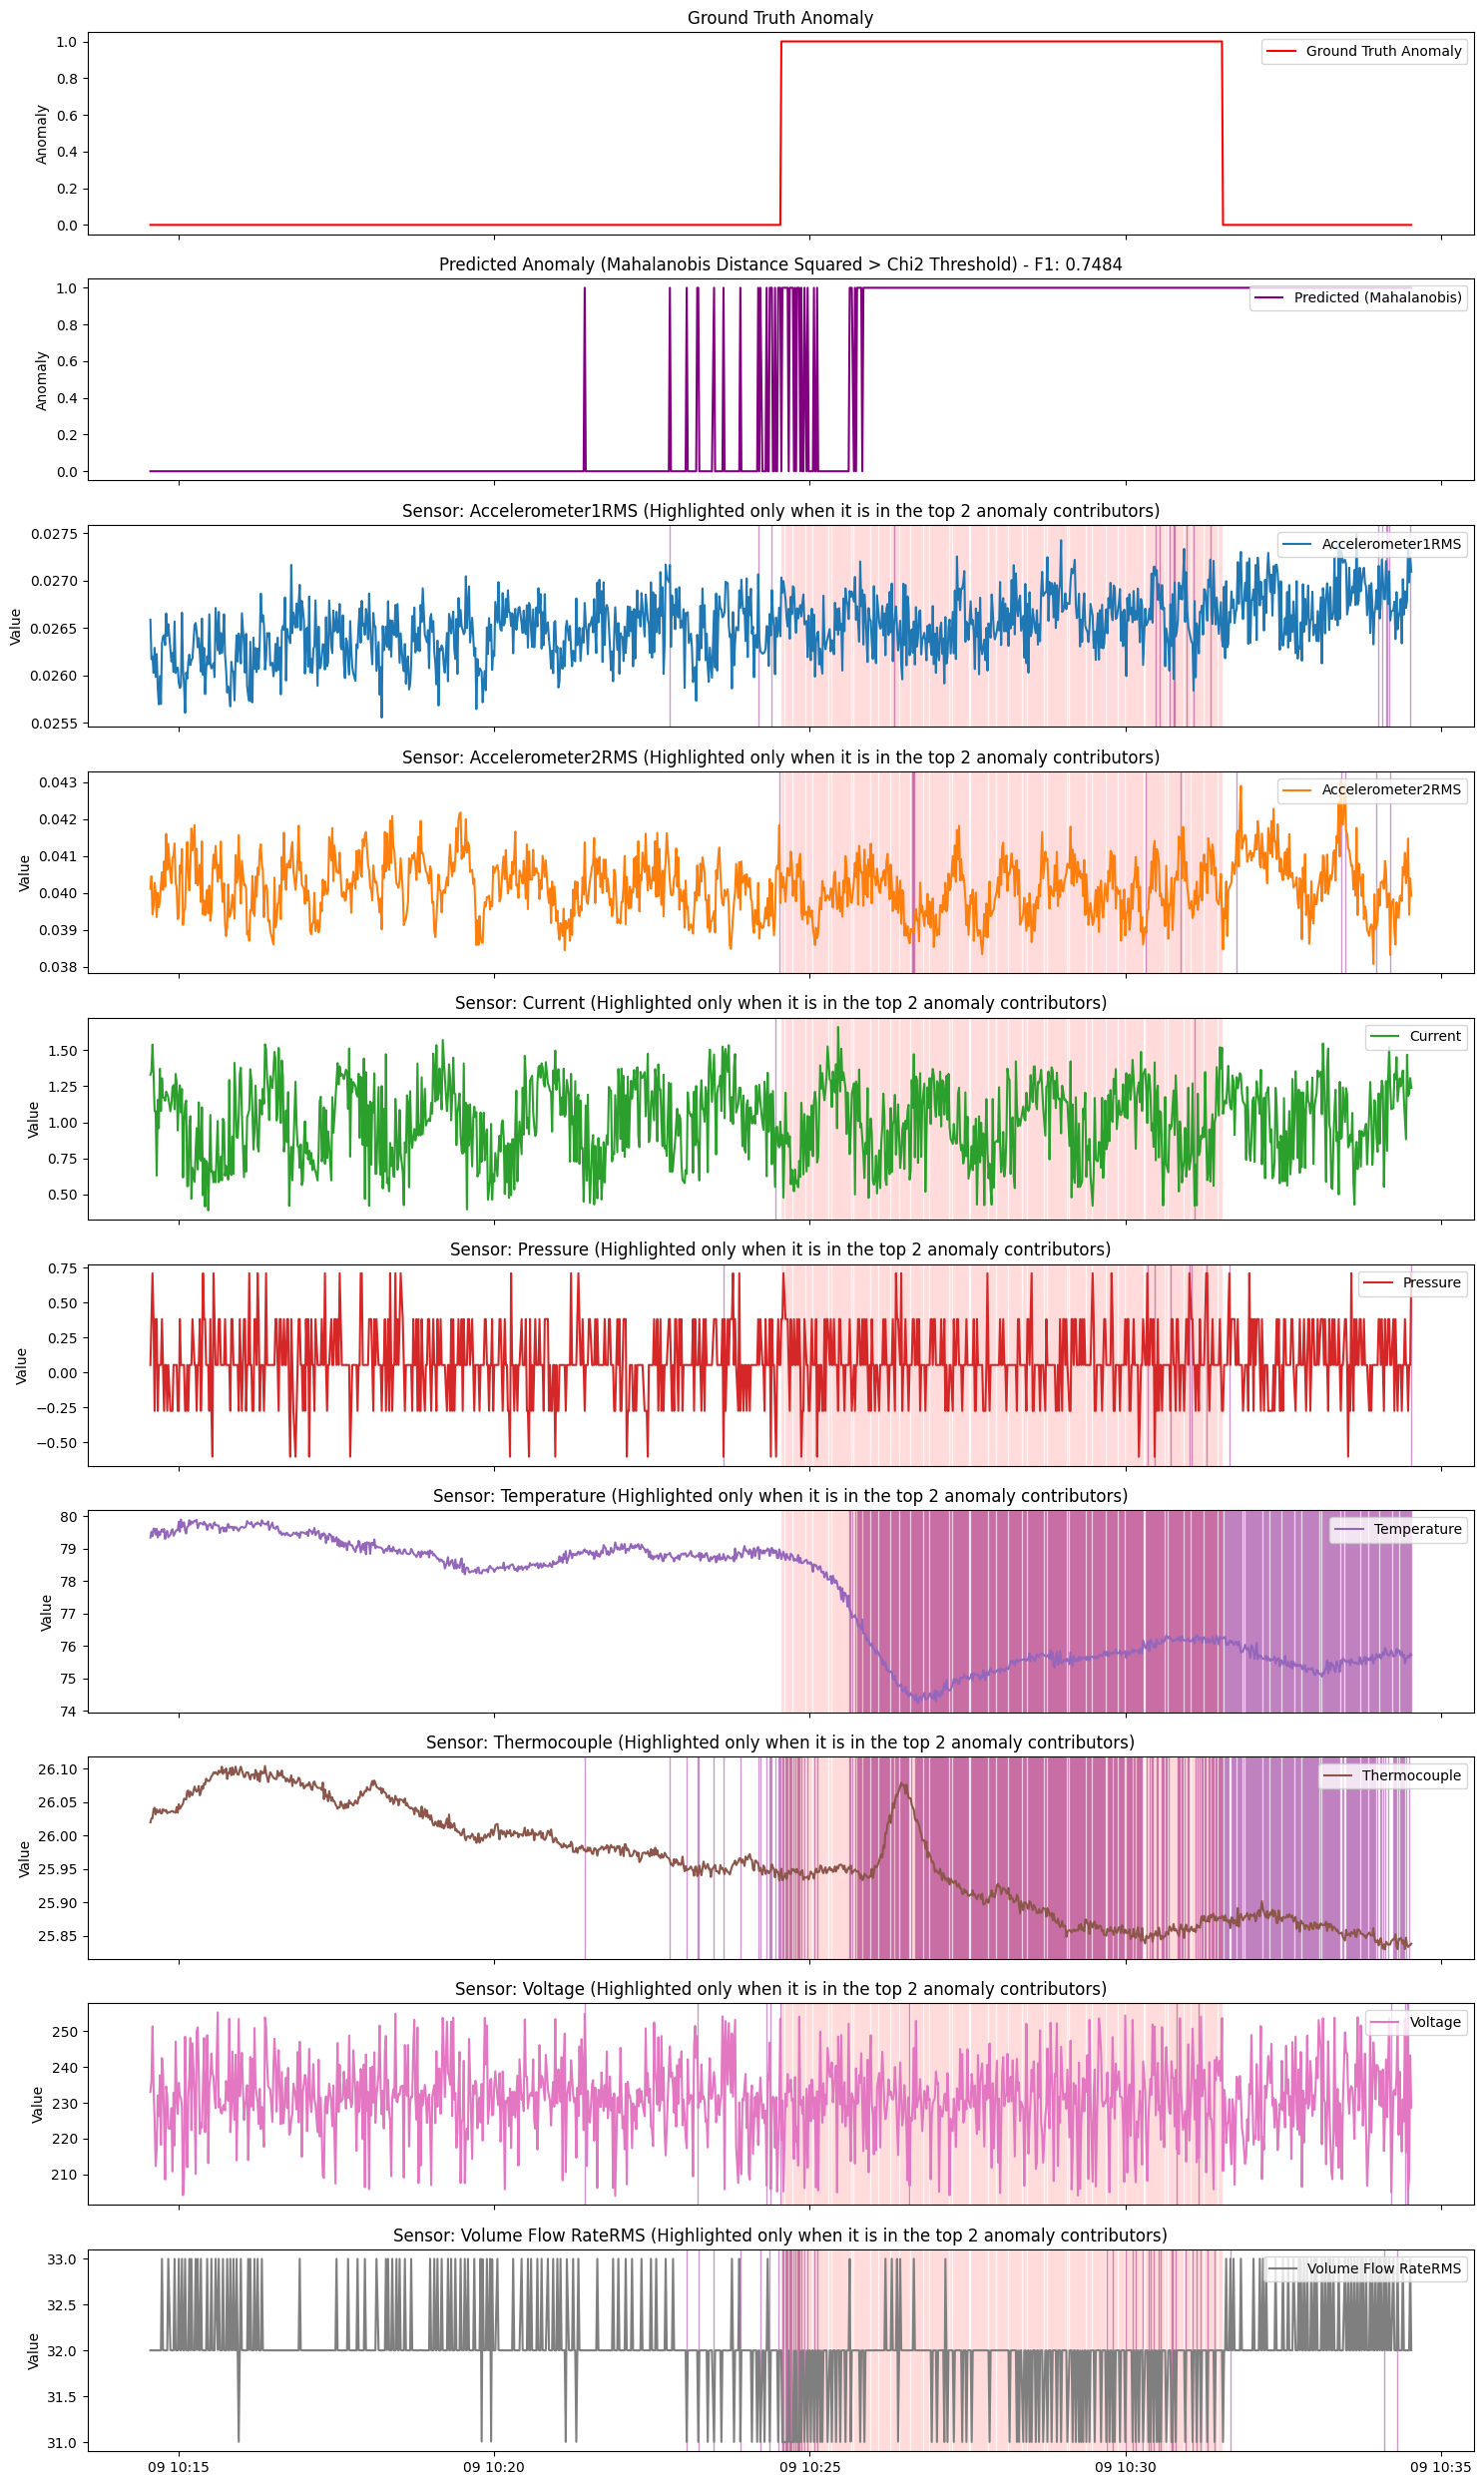

In [38]:
# Plot Multivariate Mahalanobis Predictions with Contribution Analysis
fig, axes = plt.subplots(nrows=len(features) + 2, ncols=1, figsize=(15, 25), sharex=True)

axes[0].plot(test.index, test['anomaly'], color='red', label='Ground Truth Anomaly')
axes[0].set_title('Ground Truth Anomaly')
axes[0].set_ylabel('Anomaly')
axes[0].legend(loc='upper right')

axes[1].plot(test.index, test['anomaly_mahal'], color='purple', label='Predicted (Mahalanobis)')
axes[1].set_title(f'Predicted Anomaly (Mahalanobis Distance Squared > Chi2 Threshold) - F1: {f1_mahal:.4f}')
axes[1].set_ylabel('Anomaly')
axes[1].legend(loc='upper right')

for i, col in enumerate(features):
    ax = axes[i + 2]
    ax.plot(test.index, test[col], color=f'C{i}', label=col)
    
    # Highlight Mahalanobis anomalies ONLY if this sensor was in the top 2 contributors
    is_anomaly = test['anomaly_mahal'] == 1
    is_top_contributor = (test['mahal_top1_contributor'] == col) | (test['mahal_top2_contributor'] == col)
    sensor_mahal_anomalies = test[is_anomaly & is_top_contributor].index
    
    for anomaly_time in sensor_mahal_anomalies:
        ax.axvspan(anomaly_time, anomaly_time, color='purple', alpha=0.4)
        
    # Also highlight ground truth for reference
    gt_anomalies = test[test['anomaly'] == 1].index
    for gt_time in gt_anomalies:
        ax.axvspan(gt_time, gt_time, color='red', alpha=0.1)
        
    ax.set_title(f'Sensor: {col} (Highlighted only when it is in the top 2 anomaly contributors)')
    ax.set_ylabel('Value')
    ax.legend(loc='upper right')

plt.tight_layout()
plt.show()


## 4. Extension: Hotelling's T² with Contribution Analysis

We apply the exact same contribution logic to the Hotelling's T² threshold (alpha=0.001) which provides an F-distribution adjusted control limit.

In [39]:
# Threshold based on F-distribution for Hotelling's T^2
n = len(train)
alpha = 0.001  # 99.9% confidence level

# UCL Formula: p * (n - 1) * (n + 1) / (n * (n - p)) * F(alpha, p, n - p)
F_val = f.ppf(1 - alpha, p, n - p)
UCL = (p * (n - 1) * (n + 1)) / (n * (n - p)) * F_val

print(f"Hotelling's T2 UCL (Upper Control Limit): {UCL:.4f}")

# Identify anomalies
test['anomaly_t2'] = (test['t2_score'] > UCL).astype(int)

f1_t2 = print_metrics(test['anomaly'], test['anomaly_t2'], "Multivariate Hotelling's T2")


Hotelling's T2 UCL (Upper Control Limit): 27.3511
--- Multivariate Hotelling's T2 ---
Confusion Matrix: [TN: 561, FP: 185 / FN: 53, TP: 348]
Precision: 0.6529
Recall:    0.8678
F1 Score:  0.7452
-----------------------------------


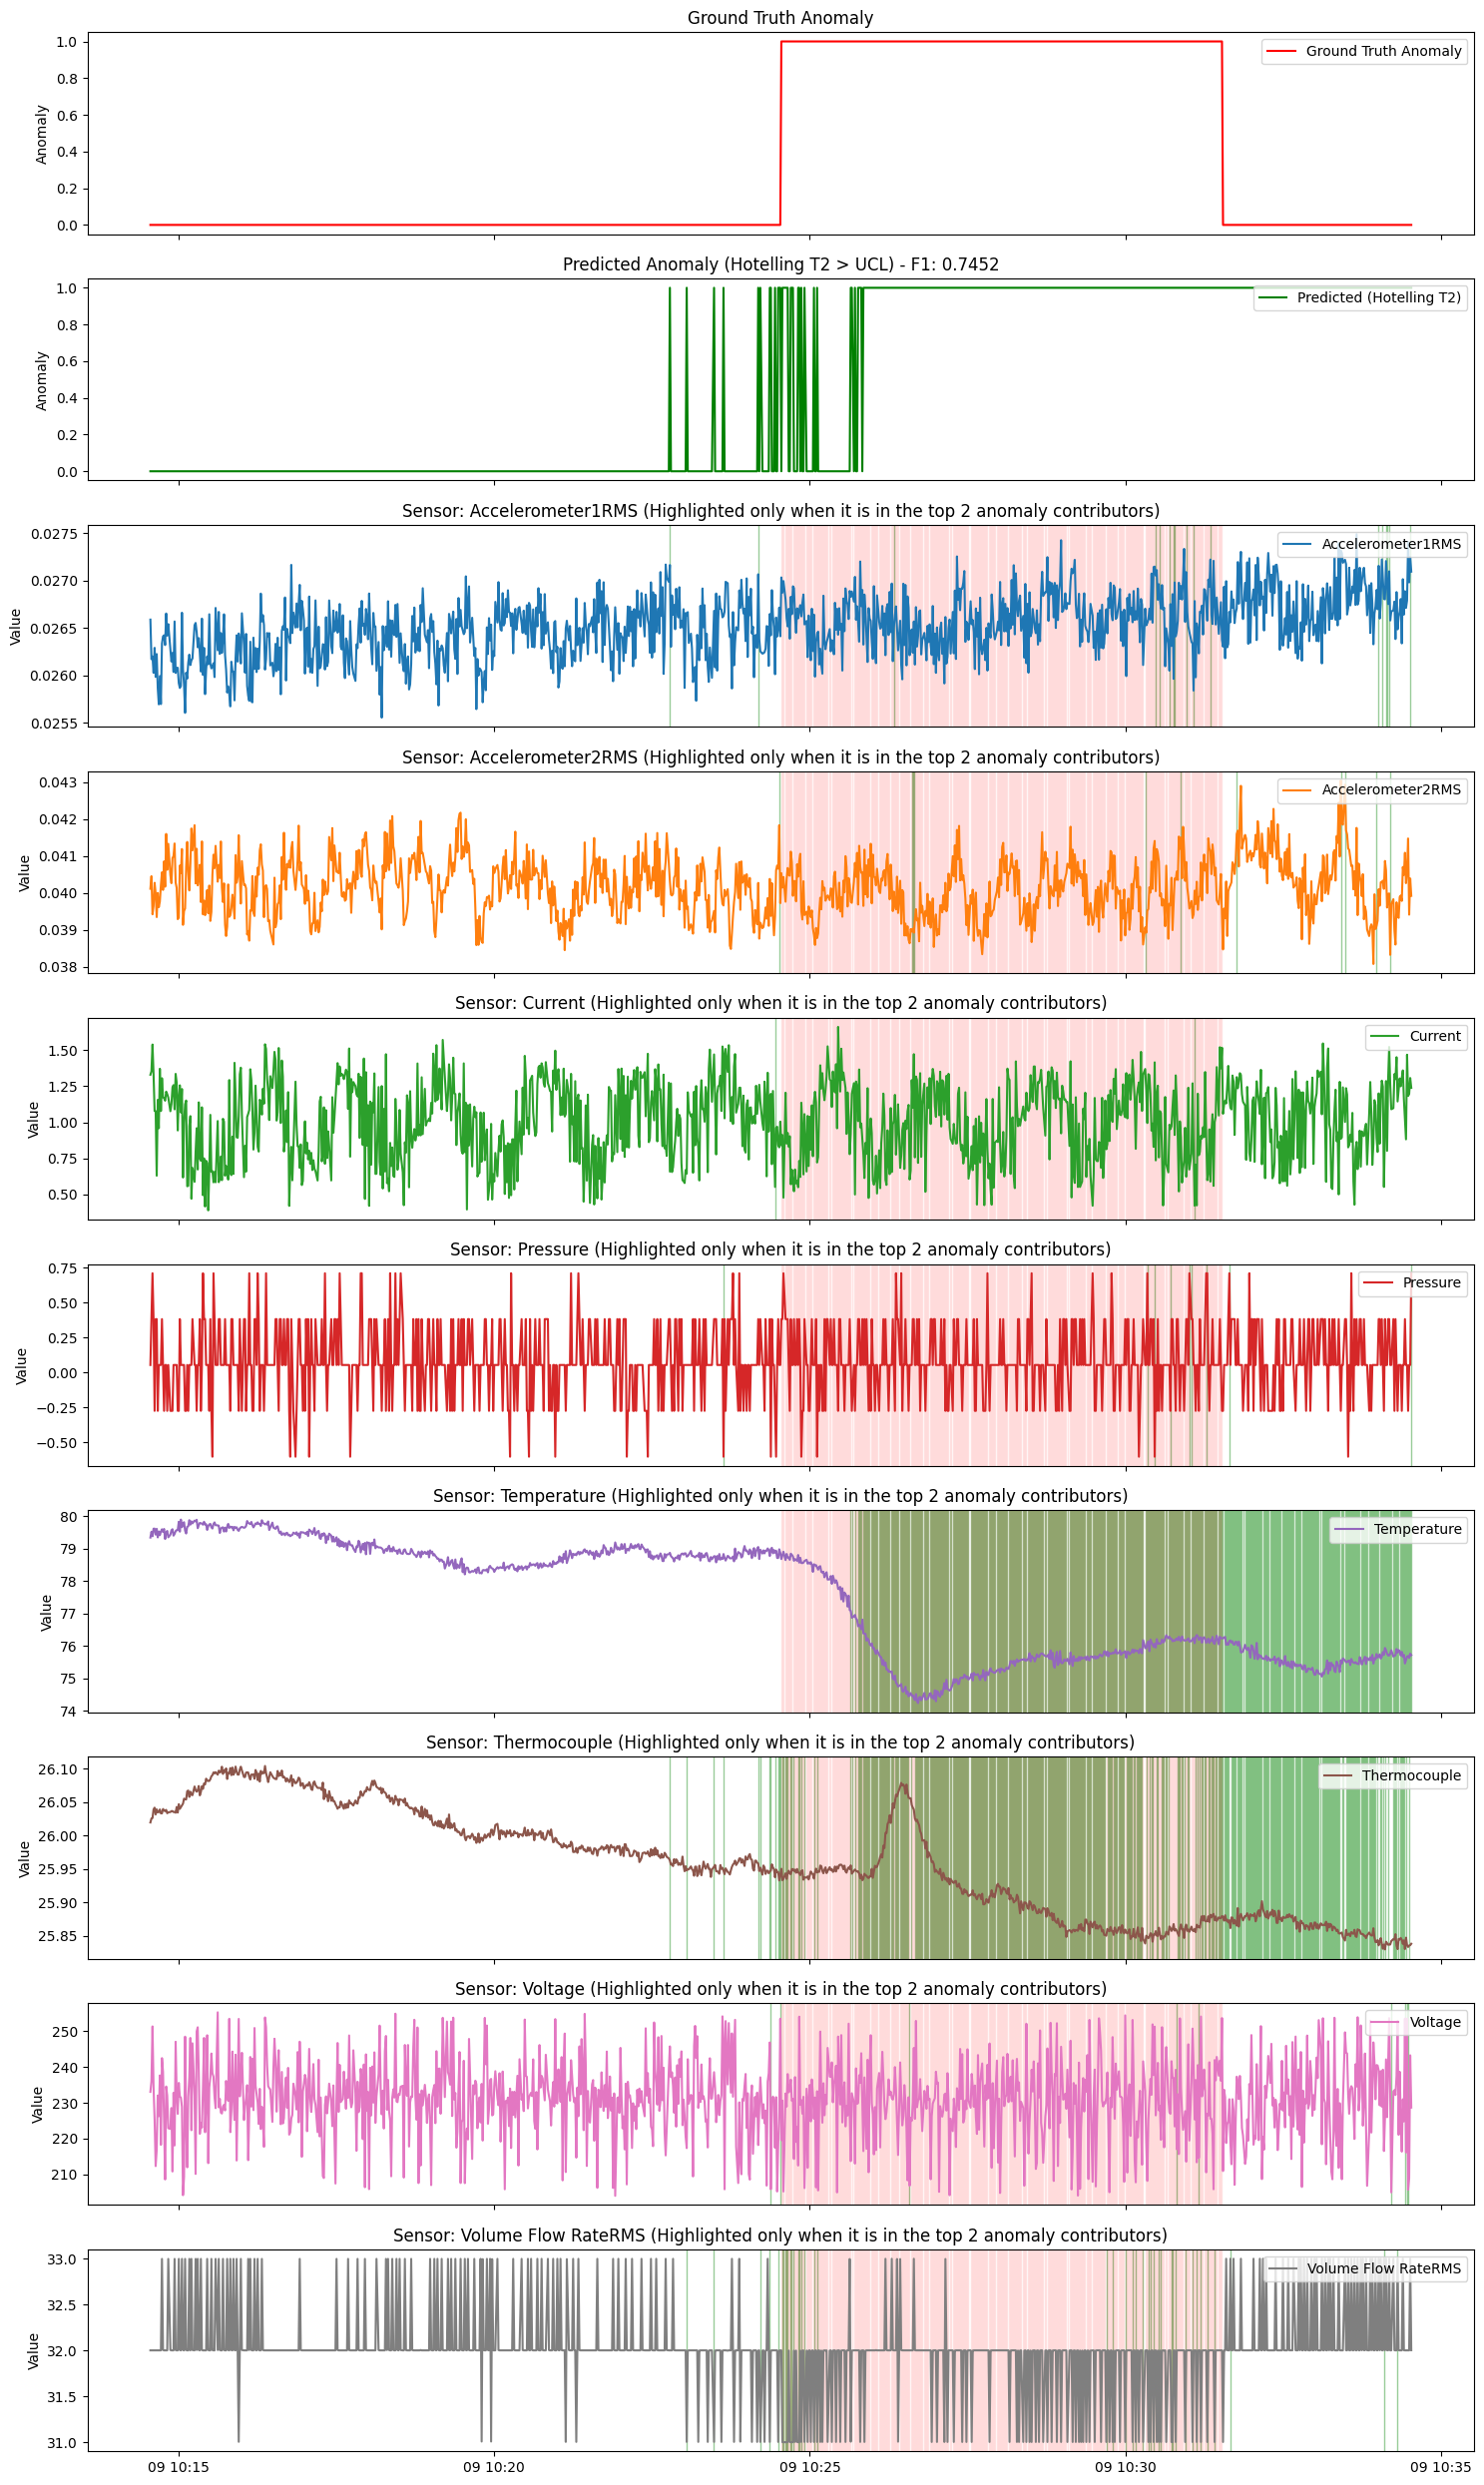

In [40]:
# Plot Hotelling's T2 Predictions with Contribution Analysis
fig, axes = plt.subplots(nrows=len(features) + 2, ncols=1, figsize=(15, 25), sharex=True)

# Plot ground truth anomaly
axes[0].plot(test.index, test['anomaly'], color='red', label='Ground Truth Anomaly')
axes[0].set_title('Ground Truth Anomaly')
axes[0].set_ylabel('Anomaly')
axes[0].legend(loc='upper right')

# Plot predicted anomaly (Hotelling T2)
axes[1].plot(test.index, test['anomaly_t2'], color='green', label='Predicted (Hotelling T2)')
axes[1].set_title(f'Predicted Anomaly (Hotelling T2 > UCL) - F1: {f1_t2:.4f}')
axes[1].set_ylabel('Anomaly')
axes[1].legend(loc='upper right')

for i, col in enumerate(features):
    ax = axes[i + 2]
    ax.plot(test.index, test[col], color=f'C{i}', label=col)
    
    # Highlight Hotelling anomalies ONLY if this sensor was in the top 2 contributors
    is_anomaly_t2 = test['anomaly_t2'] == 1
    is_top_contributor = (test['mahal_top1_contributor'] == col) | (test['mahal_top2_contributor'] == col)
    sensor_t2_anomalies = test[is_anomaly_t2 & is_top_contributor].index
    
    for anomaly_time in sensor_t2_anomalies:
        ax.axvspan(anomaly_time, anomaly_time, color='green', alpha=0.4)
        
    gt_anomalies = test[test['anomaly'] == 1].index
    for gt_time in gt_anomalies:
        ax.axvspan(gt_time, gt_time, color='red', alpha=0.1)
        
    ax.set_title(f'Sensor: {col} (Highlighted only when it is in the top 2 anomaly contributors)')
    ax.set_ylabel('Value')
    ax.legend(loc='upper right')

plt.tight_layout()
plt.show()
